# BloodBridge AI — Machine Learning Model Training and Evaluation

In this notebook, we train and evaluate machine learning models to forecast next-day blood inventory shortage risk.

We compare two modeling approaches:
1. **Logistic Regression Classifier** (linear baseline)
2. **Random Forest Classifier** (non-linear ensemble)

We split the dataset chronologically (leakage-safe split) to simulate real-world model deployment, preprocess the categorical/numerical columns using scikit-learn pipelines, and visualize performance using ROC curves, confusion matrices, and feature importance charts.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Locate project root
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
    
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "reports"
print(f"Project root identified: {ROOT}")

Project root identified: C:\Users\dhair\OneDrive\Desktop\College\Project\project implementation part\BloodBridge_AI


### Load the Processed Dataset

In [2]:
input_path = DATA_DIR / "processed" / "final_feature_engineered_bloodbridge_dataset.csv"
df = pd.read_csv(input_path, parse_dates=["record_date"])

# Sort chronologically to prevent future information leakage
df = df.sort_values("record_date").reset_index(drop=True)
print(f"Loaded {len(df):,} rows.")

Loaded 25,728 rows.


### Chronological Split (80/20 Holdout)

We split the data chronologically: the first 80% of rows are used for training, and the remaining 20% are used for testing.

In [3]:
feature_names = [
    "inventory_ratio", 
    "day_of_week", 
    "month", 
    "emergency_event_flag", 
    "requests_received_rolling_7d", 
    "donations_received_rolling_7d", 
    "inventory_ratio_rolling_7d", 
    "request_donation_gap_7d",
    "city",
    "blood_group"
]
target_name = "shortage_next_day"

X = df[feature_names].copy()
y = df[target_name].astype(int)

split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train set shape: {X_train.shape} | Test set shape: {X_test.shape}")
print(f"Train shortage rate: {y_train.mean():.2%} | Test shortage rate: {y_test.mean():.2%}")

Train set shape: (20582, 10) | Test set shape: (5146, 10)
Train shortage rate: 25.77% | Test shortage rate: 26.10%


### Preprocessing Pipeline

We group features into numeric and categorical types and build a standard preprocessing pipeline.

In [4]:
categorical_cols = ["city", "blood_group"]
numeric_cols = [col for col in feature_names if col not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_cols),
    ("categorical", categorical_transformer, categorical_cols)
])

### Model Training: Baseline Logistic Regression vs. Random Forest

We fit both models on our training set.

In [5]:
# 1. Logistic Regression Model
lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# 2. Random Forest Classifier Model
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1))
])

print("Fitting Logistic Regression baseline...")
lr_pipeline.fit(X_train, y_train)

print("Fitting Random Forest ensemble...")
rf_pipeline.fit(X_train, y_train)

print("Models trained successfully.")

Fitting Logistic Regression baseline...


Fitting Random Forest ensemble...


Models trained successfully.


### Model Performance Evaluation

We predict probabilities on the test set and calculate evaluation metrics.

In [6]:
# Predictions and probabilities
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

def get_metrics_dict(name, y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
    }

lr_metrics = get_metrics_dict("Logistic Regression", y_test, lr_preds, lr_probs)
rf_metrics = get_metrics_dict("Random Forest", y_test, rf_preds, rf_probs)

comparison_df = pd.DataFrame([lr_metrics, rf_metrics]).drop(columns="confusion_matrix")
display(comparison_df)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9767,0.9214,0.9955,0.9571,0.9979
1,Random Forest,0.9804,0.9349,0.9940,0.9636,0.9978


### Visualizations

Let's visualize the performance curves and feature importances.

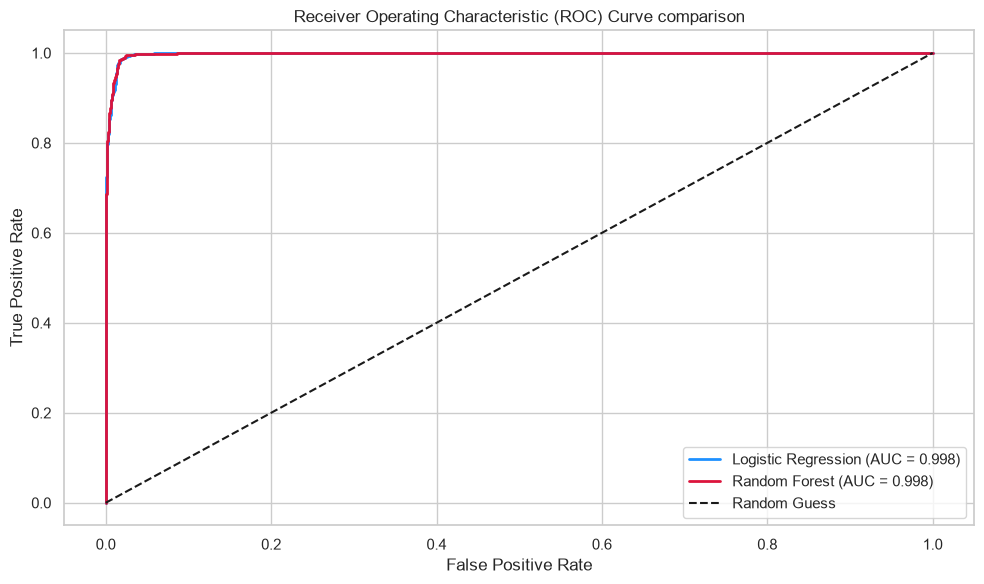

In [7]:
# 1. Plot Receiver Operating Characteristic (ROC) Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(10, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_metrics['roc_auc']:.3f})", color="dodgerblue", lw=2)
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_metrics['roc_auc']:.3f})", color="crimson", lw=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("Receiver Operating Characteristic (ROC) Curve comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

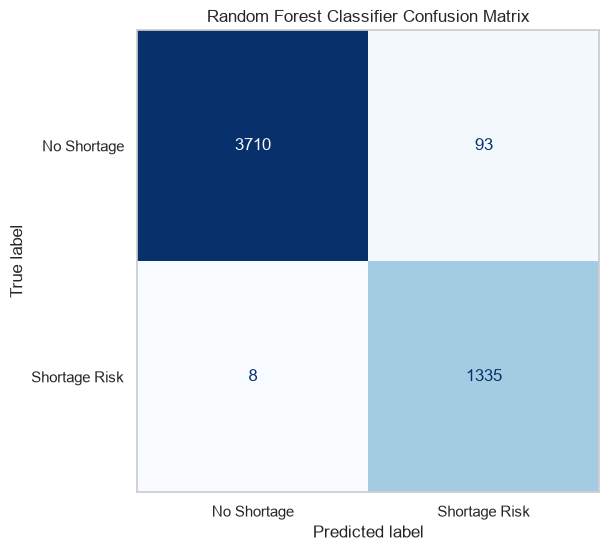

In [8]:
# 2. Plot Confusion Matrix Heatmap (for best performing Random Forest)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    rf_preds, 
    display_labels=["No Shortage", "Shortage Risk"], 
    cmap="Blues", 
    colorbar=False
)
plt.title("Random Forest Classifier Confusion Matrix")
plt.grid(False)
plt.show()

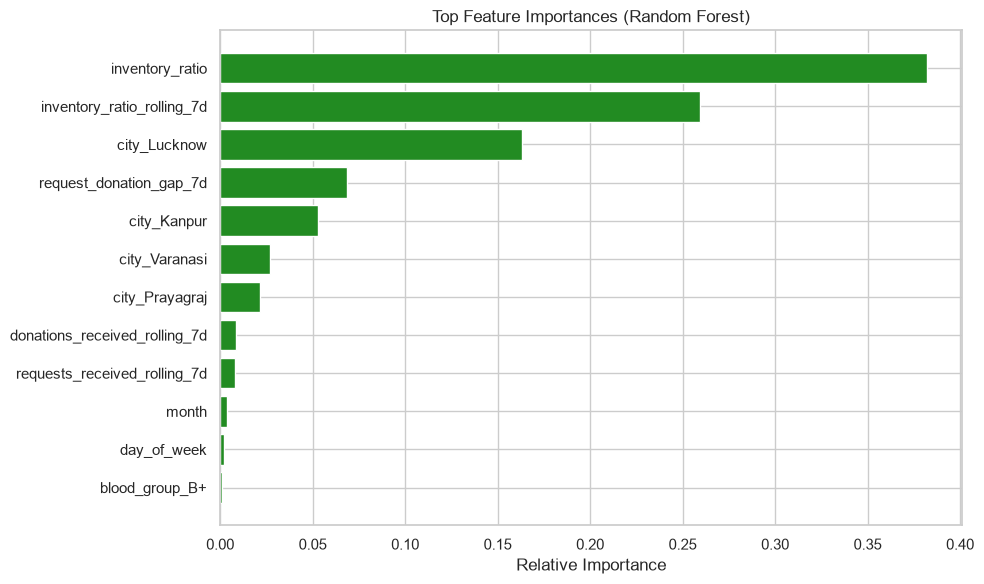

In [9]:
# 3. Plot Feature Importances (Random Forest)
preprocessor_fitted = rf_pipeline.named_steps["preprocess"]
cat_encoder = preprocessor_fitted.named_transformers_["categorical"].named_steps["onehot"]
encoded_cat_cols = list(cat_encoder.get_feature_names_out(categorical_cols))
all_features = numeric_cols + encoded_cat_cols

importances = rf_pipeline.named_steps["model"].feature_importances_
indices = np.argsort(importances)[::-1]

# Select top 12 features for visualization
top_k = min(12, len(all_features))
top_indices = indices[:top_k]

plt.figure(figsize=(10, 6))
plt.barh(
    range(top_k), 
    importances[top_indices][::-1], 
    align="center", 
    color="forestgreen"
)
plt.yticks(range(top_k), [all_features[i] for i in top_indices][::-1])
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

### Save Final Evaluation Metrics JSON

In [10]:
output_metrics = {
    "model": "random_forest_classifier",
    "evaluation": "global_chronological_holdout_80_20",
    "accuracy": rf_metrics["accuracy"],
    "precision": rf_metrics["precision"],
    "recall": rf_metrics["recall"],
    "f1": rf_metrics["f1"],
    "roc_auc": rf_metrics["roc_auc"],
    "confusion_matrix": rf_metrics["confusion_matrix"]
}

output_file = REPORTS_DIR / "model_metrics.json"
with output_file.open("w", encoding="utf-8") as f:
    json.dump(output_metrics, f, indent=4)
    
print(f"Successfully wrote evaluation metrics report to: {output_file.resolve()}")

Successfully wrote evaluation metrics report to: C:\Users\dhair\OneDrive\Desktop\College\Project\project implementation part\BloodBridge_AI\reports\model_metrics.json
